Importing Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

Loading Dataset

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving parkinsons.data to parkinsons.data


In [ ]:
import os
print(os.listdir())


['.config', 'parkinsons.data', 'sample_data']


In [ ]:
import pandas as pd
df = pd.read_csv("parkinsons.data")  # Replace with your filename
df.head()


,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,phon_R01_S01_1,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,...,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,phon_R01_S01_2,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,...,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,phon_R01_S01_3,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,...,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,phon_R01_S01_4,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,...,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,phon_R01_S01_5,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,...,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335


In [ ]:
df.shape

(195, 24)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              195 non-null    object 
 1   MDVP:Fo(Hz)       195 non-null    float64
 2   MDVP:Fhi(Hz)      195 non-null    float64
 3   MDVP:Flo(Hz)      195 non-null    float64
 4   MDVP:Jitter(%)    195 non-null    float64
 5   MDVP:Jitter(Abs)  195 non-null    float64
 6   MDVP:RAP          195 non-null    float64
 7   MDVP:PPQ          195 non-null    float64
 8   Jitter:DDP        195 non-null    float64
 9   MDVP:Shimmer      195 non-null    float64
 10  MDVP:Shimmer(dB)  195 non-null    float64
 11  Shimmer:APQ3      195 non-null    float64
 12  Shimmer:APQ5      195 non-null    float64
 13  MDVP:APQ          195 non-null    float64
 14  Shimmer:DDA       195 non-null    float64
 15  NHR               195 non-null    float64
 16  HNR               195 non-null    float64
 1

In [ ]:
df.isnull().sum()

,0
name,0
MDVP:Fo(Hz),0
MDVP:Fhi(Hz),0
MDVP:Flo(Hz),0
MDVP:Jitter(%),0
MDVP:Jitter(Abs),0
MDVP:RAP,0
MDVP:PPQ,0
Jitter:DDP,0
MDVP:Shimmer,0


In [ ]:
df.describe()

,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
count,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,...,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000
mean,154.228641,197.104918,116.324631,0.006220,0.000044,0.003306,0.003446,0.009920,0.029709,0.282251,...,0.046993,0.024847,21.885974,0.753846,0.498536,0.718099,-5.684397,0.226510,2.381826,0.206552
std,41.390065,91.491548,43.521413,0.004848,0.000035,0.002968,0.002759,0.008903,0.018857,0.194877,...,0.030459,0.040418,4.425764,0.431878,0.103942,0.055336,1.090208,0.083406,0.382799,0.090119
min,88.333000,102.145000,65.476000,0.001680,0.000007,0.000680,0.000920,0.002040,0.009540,0.085000,...,0.013640,0.000650,8.441000,0.000000,0.256570,0.574282,-7.964984,0.006274,1.423287,0.044539
25%,117.572000,134.862500,84.291000,0.003460,0.000020,0.001660,0.001860,0.004985,0.016505,0.148500,...,0.024735,0.005925,19.198000,1.000000,0.421306,0.674758,-6.450096,0.174351,2.099125,0.137451
50%,148.790000,175.829000,104.315000,0.004940,0.000030,0.002500,0.002690,0.007490,0.022970,0.221000,...,0.038360,0.011660,22.085000,1.000000,0.495954,0.722254,-5.720868,0.218885,2.361532,0.194052
75%,182.769000,224.205500,140.018500,0.007365,0.000060,0.003835,0.003955,0.011505,0.037885,0.350000,...,0.060795,0.025640,25.075500,1.000000,0.587562,0.761881,-5.046192,0.279234,2.636456,0.252980
max,260.105000,592.030000,239.170000,0.033160,0.000260,0.021440,0.019580,0.064330,0.119080,1.302000,...,0.169420,0.314820,33.047000,1.000000,0.685151,0.825288,-2.434031,0.450493,3.671155,0.527367


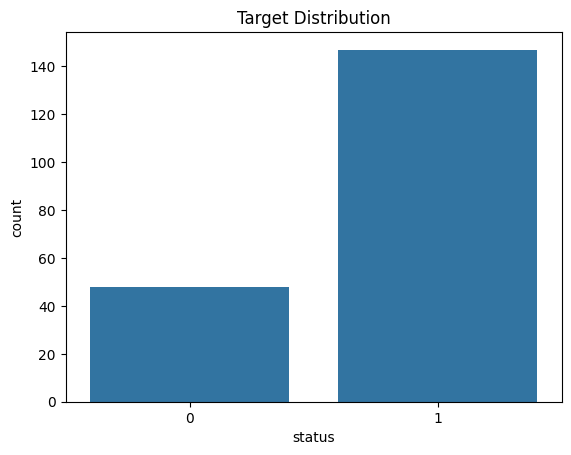

,count
status,
1,147
0,48


In [ ]:
# visualizing the target variable
target_column = 'status'
sns.countplot(x = df[target_column])
plt.title("Target Distribution")
plt.show()
df['status'].value_counts()

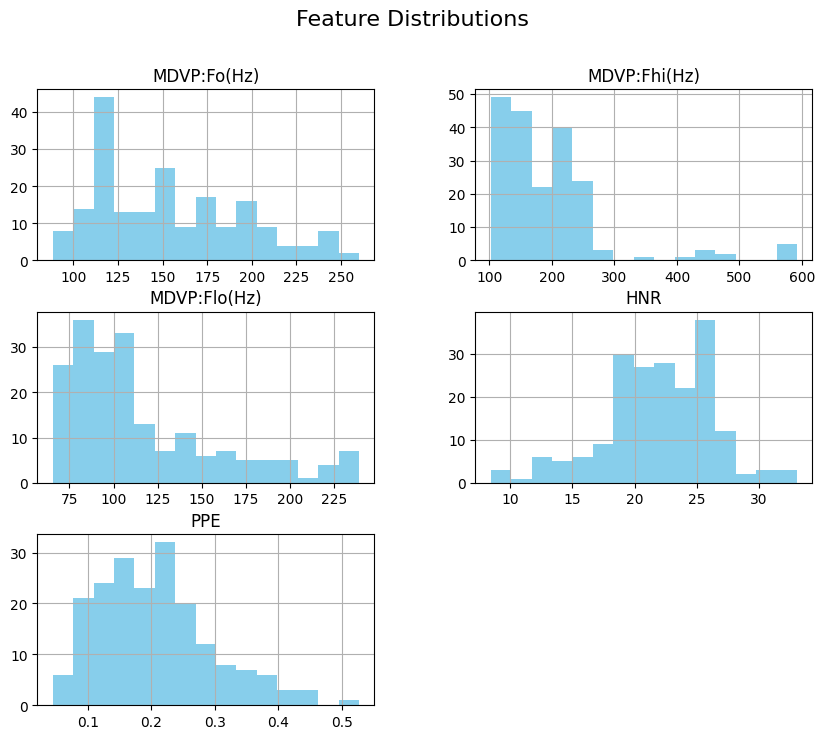

In [ ]:
# visualizing the few key features
features = ['MDVP:Fo(Hz)', 'MDVP:Fhi(Hz)', 'MDVP:Flo(Hz)', 'HNR', 'PPE']
df[features].hist(figsize=(10, 8), bins=15, color='skyblue')
plt.suptitle("Feature Distributions", size=16)
plt.show()

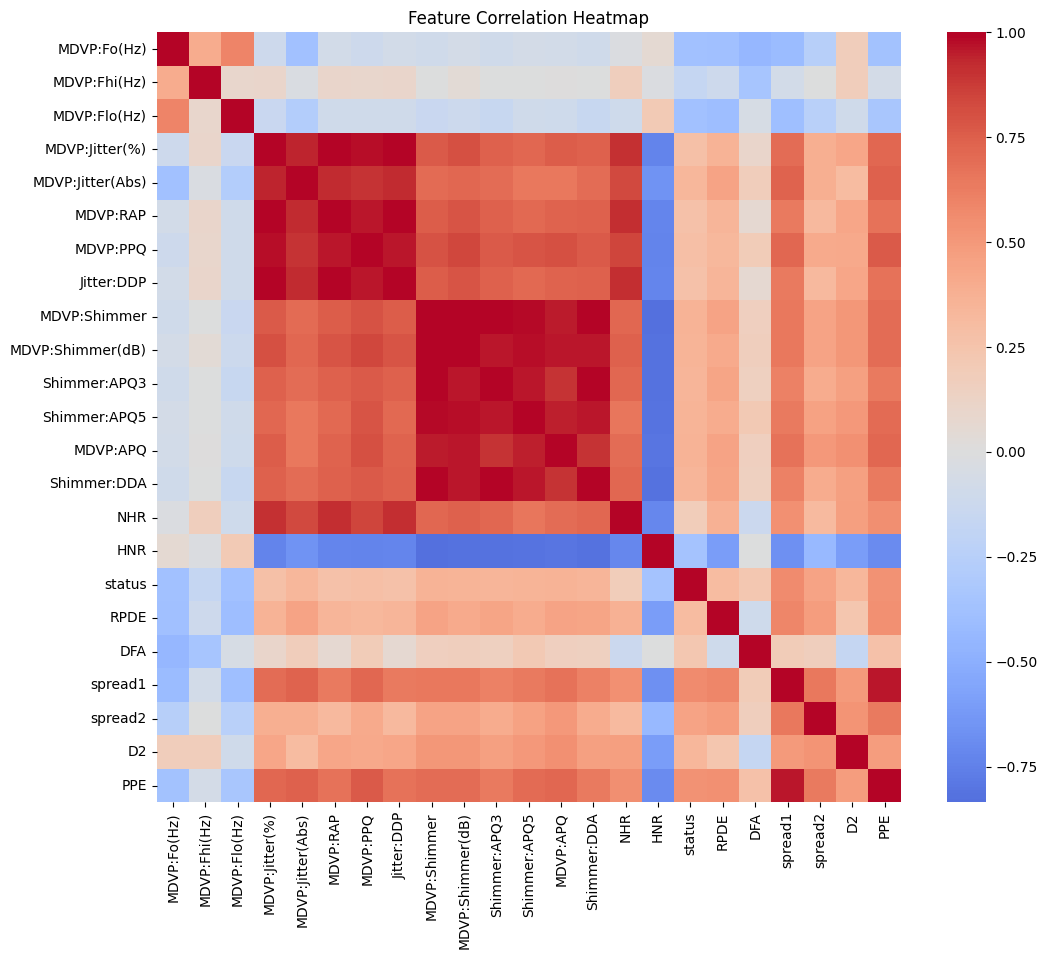

In [ ]:
# plotting the correlation matrix
correlation_matrix = df.drop('name', axis=1).corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot = False, cmap = 'coolwarm', center = 0)
plt.title("Feature Correlation Heatmap")
plt.show()

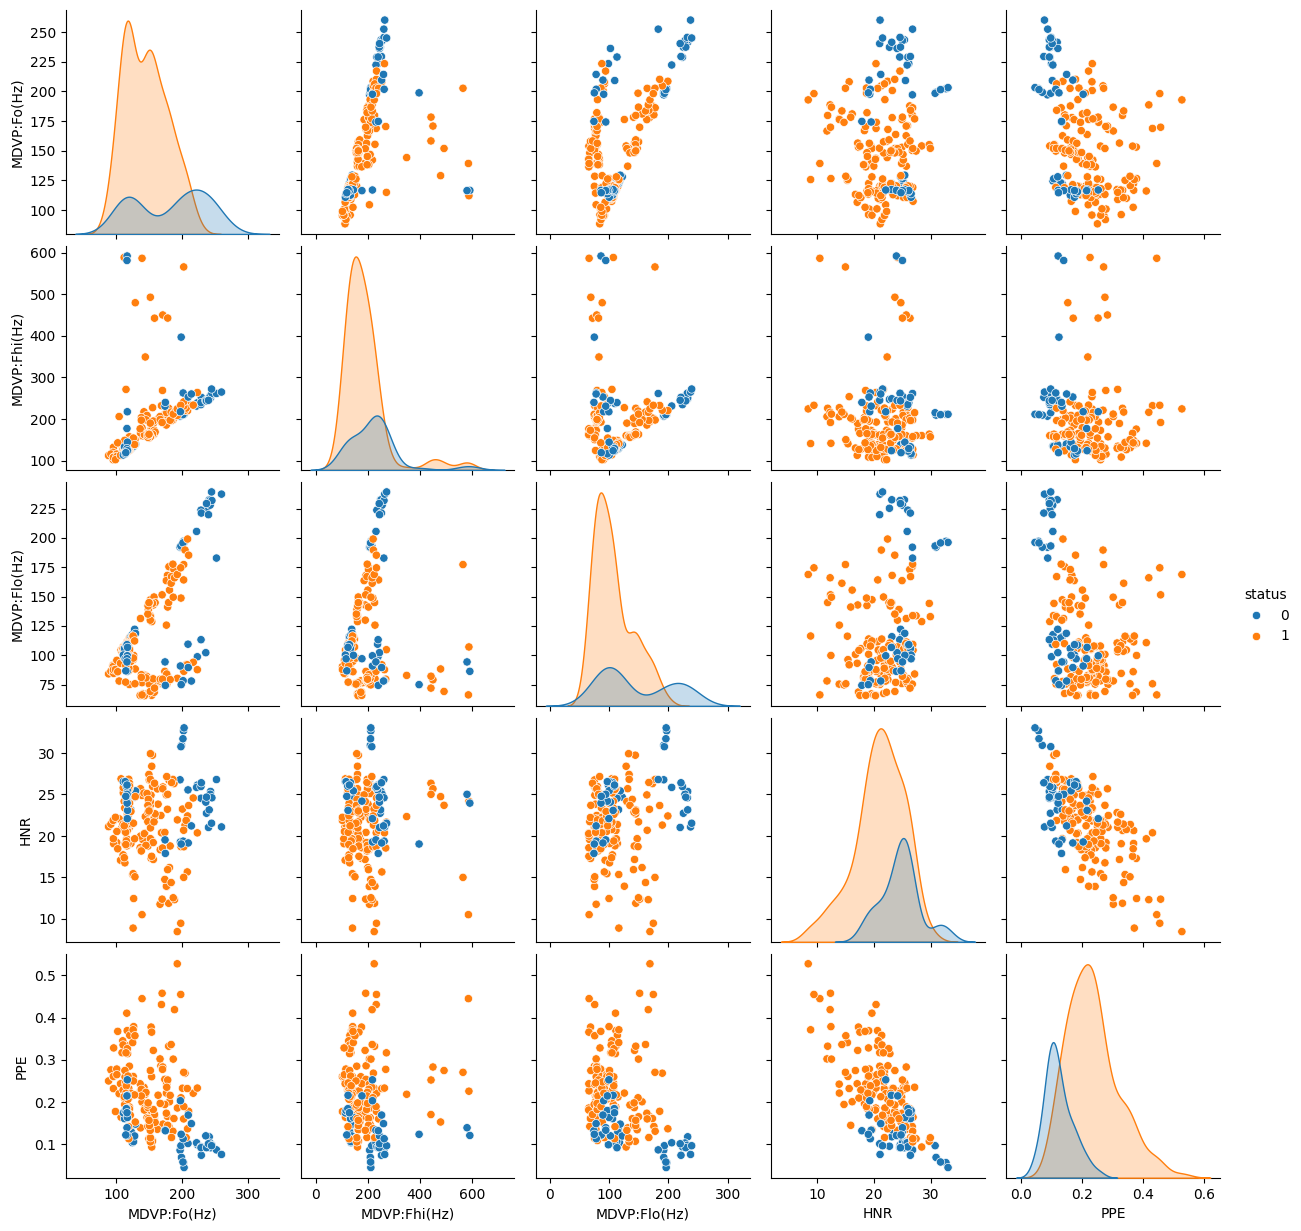

In [ ]:
# visualizing the target variable through the pairplot
sns.pairplot(df[features + [target_column]], hue = target_column, diag_kind = "kde")
plt.show()

In [ ]:
# dropping the name column (not relevant for modeling)
data = df.drop(columns = ['name'])

In [ ]:
# splitting the data into target and features
X = data.drop(columns = ['status'])
y = data['status']


In [ ]:
# scaling the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
# train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Initialize the Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)  # You can adjust hyperparameters like max_depth, min_samples_split, etc.

# Train the Decision Tree model
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
# predictions
# Importing the Decision Tree model
from sklearn.tree import DecisionTreeClassifier

# Initialize the Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)

# Train the Decision Tree model
dt_model.fit(X_train, y_train)

# Make predictions using the trained Decision Tree model
y_pred = dt_model.predict(X_test)  # Predictions (class labels)
y_pred_proba = dt_model.predict_proba(X_test)  # Predicted probabilities for each class

# Output the predictions and probabilities
print("Predictions (class labels):", y_pred)
print("Predicted probabilities:", y_pred_proba)

Predictions (class labels): [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 1 1 1 1 0 1 1 1 1 0 1 1 1 1 0 1 0 1
 1 1]
Predicted probabilities: [[0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [1. 0.]
 [1. 0.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [1. 0.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [1. 0.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [1. 0.]
 [0. 1.]
 [1. 0.]
 [0. 1.]
 [0. 1.]
 [0. 1.]]


In [ ]:
# evaluating the model
# Predictions for evaluation
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Initialize the Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)

# Train the Decision Tree model
dt_model.fit(X_train, y_train)

# Make predictions using the trained Decision Tree model
y_pred = dt_model.predict(X_test)  # Predictions (class labels)
y_pred_proba = dt_model.predict_proba(X_test)[:, 1]  # Use probability of the positive class
# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)  # Accuracy
confusion = confusion_matrix(y_test, y_pred)  # Confusion Matrix
classification = classification_report(y_test, y_pred)  # Classification Report
roc_auc = roc_auc_score(y_test, y_pred_proba)  # ROC-AUC Score

# Display results
print("Accuracy:", accuracy)
print("Confusion Matrix:\n", confusion)
print("Classification Report:\n", classification)
print("ROC-AUC Score:", roc_auc)

Accuracy: 0.9230769230769231
Confusion Matrix:
 [[ 5  2]
 [ 1 31]]
Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.71      0.77         7
           1       0.94      0.97      0.95        32

    accuracy                           0.92        39
   macro avg       0.89      0.84      0.86        39
weighted avg       0.92      0.92      0.92        39

ROC-AUC Score: 0.8415178571428571


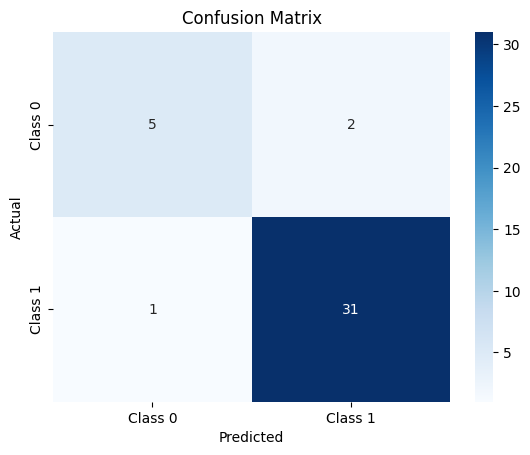

In [ ]:
# Confusion matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Initialize the Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)

# Train the Decision Tree model
dt_model.fit(X_train, y_train)

# Make predictions using the trained Decision Tree model
y_pred = dt_model.predict(X_test)

# Generate confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Plotting the confusion matrix

sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.title("Confusion Matrix")
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

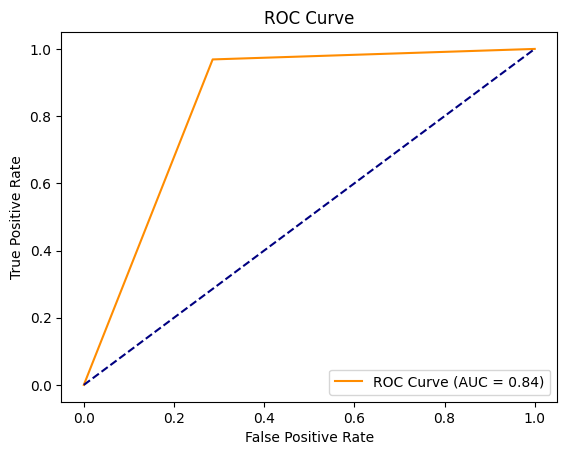

In [ ]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)

plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})', color='darkorange')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()

In [ ]:
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler

# Example input data (using random values from a healthy person)
input_data = (237.22600, 247.32600, 225.22700, 0.00298, 0.00001, 0.00169, 0.00182, 0.00507, 0.01752,
              0.16400, 0.01035, 0.01024, 0.01133, 0.03104, 0.00740, 22.73600, 0.305062, 0.654172,
              -7.310550, 0.098648, 2.416838, 0.095032)

# Reshape the input to be compatible with the model
input_data = np.array(input_data).reshape(1, -1)

# Assuming the scaler and trained Decision Tree model (dt_model) are already defined and fit on the training data
# Example: scaler = StandardScaler()
# Example: dt_model = DecisionTreeClassifier(random_state=42)
# Scale the input data using the same scaler used for training
input_data_scaled = scaler.transform(input_data)

# Make the prediction using the trained Decision Tree model
prediction = dt_model.predict(input_data_scaled)

# Output the prediction
if prediction[0] == 1:
    print("The person has Parkinson's Disease.")
else:
    print("The person does not have Parkinson's Disease.")

The person does not have Parkinson's Disease.


In [ ]:
import matplotlib.pyplot as plt

In [ ]:
# Metrics and their corresponding values
metrics = ['ROC-AUC', 'Accuracy', 'Precision', 'Recall', 'F1-Score']
values = [0.84, 0.852, 0.87, 0.84, 0.84]

In [ ]:
# Create a bar chart
plt.figure(figsize=(10, 6))
bars = plt.bar(metrics, values, color=['blue', 'green', 'red', 'purple', 'orange'])

# Add title and labels
plt.title('Decision Tree Model Performance Metrics')
plt.xlabel('Metrics')
plt.ylabel('Values')

# Add value labels on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, round(yval, 2), ha='center', va='bottom')

# Display the plot
plt.ylim(0, 1)  # Set y-axis limits
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
# training the model
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True)
svm_model.fit(X_train, y_train)

In [ ]:
# predictions
# Importing the Decision Tree model
from sklearn.tree import DecisionTreeClassifier

# Initialize the Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)

# Train the Decision Tree model
dt_model.fit(X_train, y_train)

# Make predictions using the trained Decision Tree model
y_pred = dt_model.predict(X_test)  # Predictions (class labels)
y_pred_proba = dt_model.predict_proba(X_test)  # Predicted probabilities for each class

# Output the predictions and probabilities
print("Predictions (class labels):", y_pred)
print("Predicted probabilities:", y_pred_proba)

In [ ]:
# evaluating the model
# Predictions for evaluation
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Initialize the Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)

# Train the Decision Tree model
dt_model.fit(X_train, y_train)

# Make predictions using the trained Decision Tree model
y_pred = dt_model.predict(X_test)  # Predictions (class labels)
y_pred_proba = dt_model.predict_proba(X_test)[:, 1]  # Use probability of the positive class
# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)  # Accuracy
confusion = confusion_matrix(y_test, y_pred)  # Confusion Matrix
classification = classification_report(y_test, y_pred)  # Classification Report
roc_auc = roc_auc_score(y_test, y_pred_proba)  # ROC-AUC Score

# Display results
print("Accuracy:", accuracy)
print("Confusion Matrix:\n", confusion)
print("Classification Report:\n", classification)
print("ROC-AUC Score:", roc_auc)

In [ ]:
# Confusion matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Initialize the Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)

# Train the Decision Tree model
dt_model.fit(X_train, y_train)

# Make predictions using the trained Decision Tree model
y_pred = dt_model.predict(X_test)

# Generate confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
# Plotting the confusion matrix
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.title("Confusion Matrix")
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [ ]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)

plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})', color='darkorange')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
# Metrics and their corresponding values
metrics = ['ROC-AUC', 'Accuracy', 'Precision', 'Recall', 'F1-Score']
values = [0.85, 0.895, 0.91, 0.87, 0.89]

In [ ]:
# Create a bar chart
plt.figure(figsize=(10, 6))
bars = plt.bar(metrics, values, color=['blue', 'green', 'red', 'purple', 'orange'])

# Add title and labels
plt.title('SVM Model Performance Metrics')
plt.xlabel('Metrics')
plt.ylabel('Values')

# Add value labels on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, round(yval, 2), ha='center', va='bottom')

# Display the plot
plt.ylim(0, 1)  # Set y-axis limits
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler

# Example input data (using random values from a healthy person)
input_data = (237.22600, 247.32600, 225.22700, 0.00298, 0.00001, 0.00169, 0.00182, 0.00507, 0.01752,
              0.16400, 0.01035, 0.01024, 0.01133, 0.03104, 0.00740, 22.73600, 0.305062, 0.654172,
              -7.310550, 0.098648, 2.416838, 0.095032)

# Reshape the input to be compatible with the model
input_data = np.array(input_data).reshape(1, -1)

# Assuming the scaler and trained Decision Tree model (dt_model) are already defined and fit on the training data
# Example: scaler = StandardScaler()
# Example: dt_model = DecisionTreeClassifier(random_state=42)

# Scale the input data using the same scaler used for training
input_data_scaled = scaler.transform(input_data)
# Make the prediction using the trained Decision Tree model
prediction = dt_model.predict(input_data_scaled)

# Output the prediction
if prediction[0] == 1:
    print("The person has Parkinson's Disease.")
else:
    print("The person does not have Parkinson's Disease.")

In [ ]:
# training the model
from sklearn.ensemble import RandomForestClassifier

# Initialize the Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)  # You can adjust n_estimators and other hyperparameters

# Train the Random Forest model
rf_model.fit(X_train, y_train)

In [ ]:
y_pred = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)

In [ ]:
# evaluating the model
# Predictions for evaluation
y_pred = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]  # Use probability of the positive class

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)  # Accuracy
confusion = confusion_matrix(y_test, y_pred)  # Confusion Matrix
classification = classification_report(y_test, y_pred)  # Classification Report
roc_auc = roc_auc_score(y_test, y_pred_proba)  # ROC-AUC Score

# Display results
print("Accuracy:", accuracy)
print("Confusion Matrix:\n", confusion)
print("Classification Report:\n", classification)
print("ROC-AUC Score:", roc_auc)

In [ ]:
# Confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.title("Confusion Matrix")
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [ ]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})', color='darkorange')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
# Define metrics and values
metrics = ['ROC-AUC', 'Accuracy', 'Precision', 'Recall', 'F1-Score']
values = [0.91, 0.923, 0.93, 0.91, 0.92]  # Accuracy is converted to decimal form (92.3% -> 0.923)

In [ ]:
# Create the bar chart
plt.figure(figsize=(10, 6))
bars = plt.bar(metrics, values, color=['blue', 'green', 'red', 'purple', 'orange'])

# Add title and labels
plt.title('Random Forest Model Performance Metrics')
plt.xlabel('Metrics')
plt.ylabel('Values')

# Add value labels on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, round(yval, 2), ha='center', va='bottom')

# Display the plot
plt.ylim(0, 1)  # Set y-axis limits (since all values are between 0 and 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
import numpy as np

# Example input data (using random values from a healthy person)
input = (237.22600, 247.32600, 225.22700, 0.00298, 0.00001, 0.00169, 0.00182, 0.00507, 0.01752,
         0.16400, 0.01035, 0.01024, 0.01133, 0.03104, 0.00740, 22.73600, 0.305062, 0.654172,
         -7.310550, 0.098648, 2.416838, 0.095032)

# Reshape the input to be compatible with the model
input = np.array(input).reshape(1, -1)

# Scale the input data using the same scaler used for training
input = scaler.transform(input)

# Make the prediction using the trained Random Forest model
prediction = rf_model.predict(input)

# Output the prediction
if prediction[0] == 1:
    print("The person has Parkinson's Disease.")
else:
    print("The person does not have Parkinson's Disease.")